# Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [2]:
df=pd.read_csv('student-mat.csv',sep=';')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.shape

(395, 33)

In [5]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [8]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
num_cols = df.select_dtypes(include='int64').columns
cat_cols = df.select_dtypes(include='object').columns

In [11]:
df[cat_cols].head()

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,yes,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,yes,no,yes,yes,no,no


In [12]:
df[num_cols].head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10


In [13]:
df['Medu'].value_counts()

Medu
4    131
2    103
3     99
1     59
0      3
Name: count, dtype: int64

In [14]:
df['traveltime'].value_counts()

traveltime
1    257
2    107
3     23
4      8
Name: count, dtype: int64

In [15]:
df['studytime'].value_counts()

studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64

In [16]:
df['famrel'].value_counts()

famrel
4    195
5    106
3     68
2     18
1      8
Name: count, dtype: int64

## Categorical Variable Mapping (for Better Data Exploration)

It improves **data interpretability**, **visualization clarity**, and makes results more meaningful

In [17]:
edu_map = {
    0: "none",
    1: "primary (4th grade)",
    2: "5th to 9th grade",
    3: "secondary",
    4: "higher education"
}

traveltime_map = {
    1: "<15 min",
    2: "15–30 min",
    3: "30 min–1 hour",
    4: ">1 hour"
}

studytime_map = {
    1: "<2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: ">10 hours"
}

school_map = {
    'GP': 'Gabriel Pereira',
    'MS': 'Mousinho da Silveira'
}

address_map = {
    'U': 'urban',
    'R': 'rural'
}

famsize_map = {
    'GT3': 'greater than 3',
    'LE3': 'less or equal to 3'
}

Pstatus_map = {'T': 'living together',
               'A': 'apart'
}


df["Medu"] = df["Medu"].map(edu_map)
df["Fedu"] = df["Fedu"].map(edu_map)
df["traveltime"] = df["traveltime"].map(traveltime_map)
df["studytime"] = df["studytime"].map(studytime_map)

df['school'] = df['school'].map(school_map)
df['address'] = df['address'].map(address_map)
df['famsize'] = df['famsize'].map(famsize_map)
df['Pstatus'] = df['Pstatus'].map(Pstatus_map)

In [18]:
num_cols = df.select_dtypes(include='int64').columns
cat_cols = df.select_dtypes(include='object').columns

In [19]:
df[num_cols].head()

,age,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,0,4,3,4,1,1,3,6,5,6,6
1,17,0,5,3,3,1,1,3,4,5,5,6
2,15,3,4,3,2,2,3,3,10,7,8,10
3,15,0,3,2,2,1,1,5,2,15,14,15
4,16,0,4,3,2,1,2,5,4,6,10,10


In [20]:
df[cat_cols].head()

,school,sex,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,Gabriel Pereira,F,urban,greater than 3,apart,higher education,higher education,at_home,teacher,course,...,15–30 min,2–5 hours,yes,no,no,no,yes,yes,no,no
1,Gabriel Pereira,F,urban,greater than 3,living together,primary (4th grade),primary (4th grade),at_home,other,course,...,<15 min,2–5 hours,no,yes,no,no,no,yes,yes,no
2,Gabriel Pereira,F,urban,less or equal to 3,living together,primary (4th grade),primary (4th grade),at_home,other,other,...,<15 min,2–5 hours,yes,no,yes,no,yes,yes,yes,no
3,Gabriel Pereira,F,urban,greater than 3,living together,higher education,5th to 9th grade,health,services,home,...,<15 min,5–10 hours,no,yes,yes,yes,yes,yes,yes,yes
4,Gabriel Pereira,F,urban,greater than 3,living together,secondary,secondary,other,other,home,...,<15 min,2–5 hours,no,yes,yes,no,yes,yes,no,no


## Explain of some of columns

- **reason: reason to choose this school**
- **schoolsup: extra educational support**
- **famsup: family educational support**
- **paid: extra paid classes within the course subject (Math or Portuguese)**
- **activities: extra-curricular activities**
- **nursery: attended nursery school**
- **higher: wants to take higher education**
- **internet: Internet access at home**
- **romantic: with a romantic relationship**
- **famrel: quality of family relationships (numeric: from 1 - very bad to 5 - excellent)**
- **freetime: free time after school (numeric: from 1 - very low to 5 - very high)**
- **goout: going out with friends (numeric: from 1 - very low to 5 - very high)**
- **Dalc: workday alcohol consumption (numeric: from 1 - very low to 5 - very high)**
- **Walc: weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)**
- **health: current health status (numeric: from 1 - very bad to 5 - very good)**
- **absences: number of school absences (numeric: from 0 to 93)**

# Anaylsis

## Univariate analysis

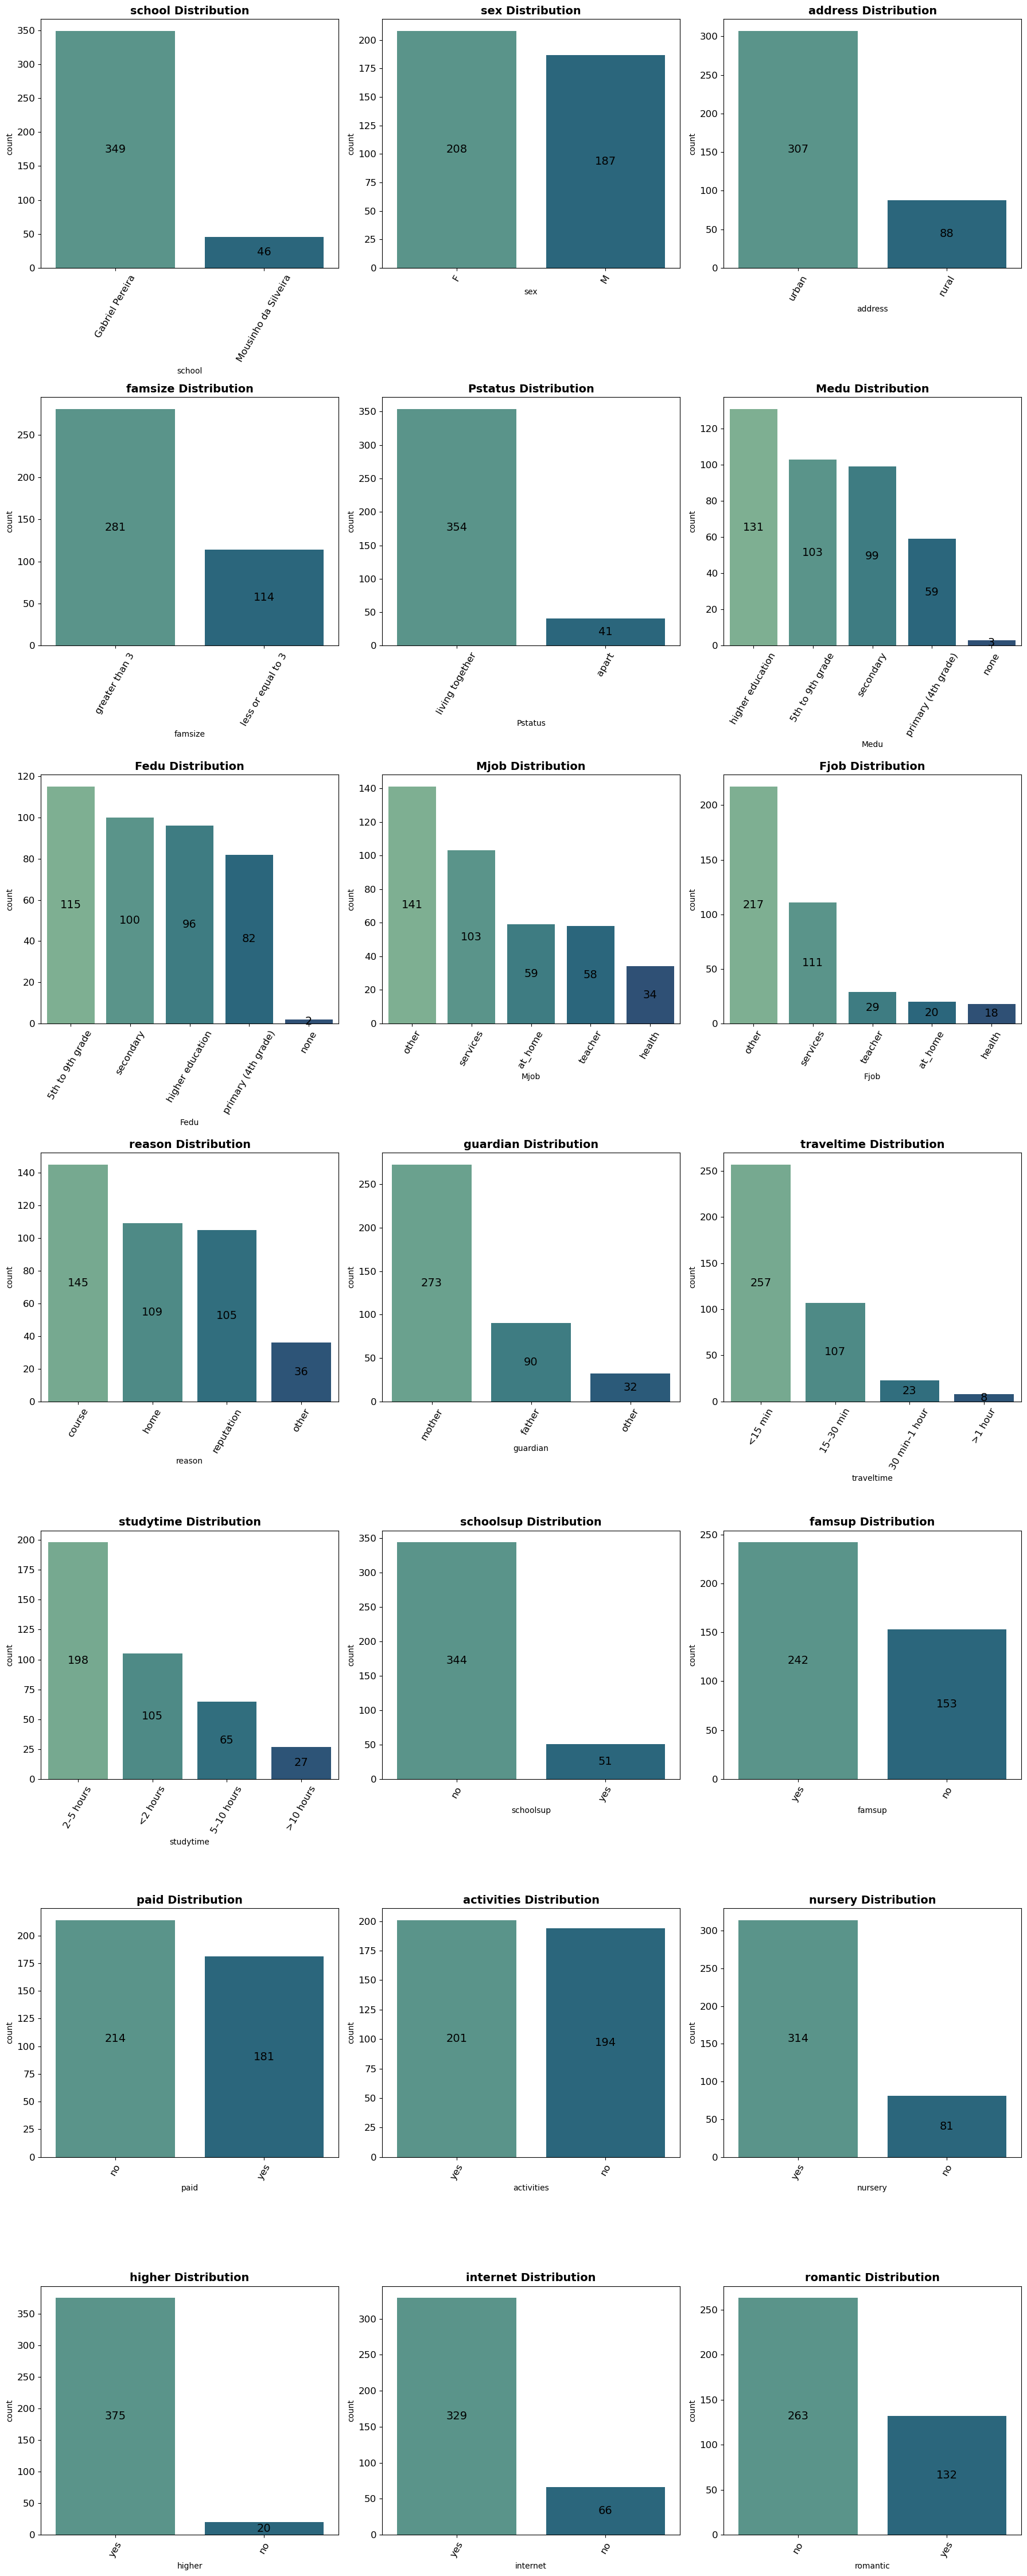

In [21]:
rows, cols = 7, 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 45))
axes = axes.flatten()

# Plot each categorical column
for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    plot = sns.countplot(data=df,
                         x=df[col_name],
                         ax=ax,
                         palette="crest",
                         order = df[col_name].value_counts().index
    )

    # Set titles and font sizes
    ax.set_title(f"{col_name} Distribution", fontsize=14, fontweight='bold')
    ax.tick_params(axis="x", rotation=60, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # Add frequency labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=14)

# Remove unused axes if cat_cols < rows*cols
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


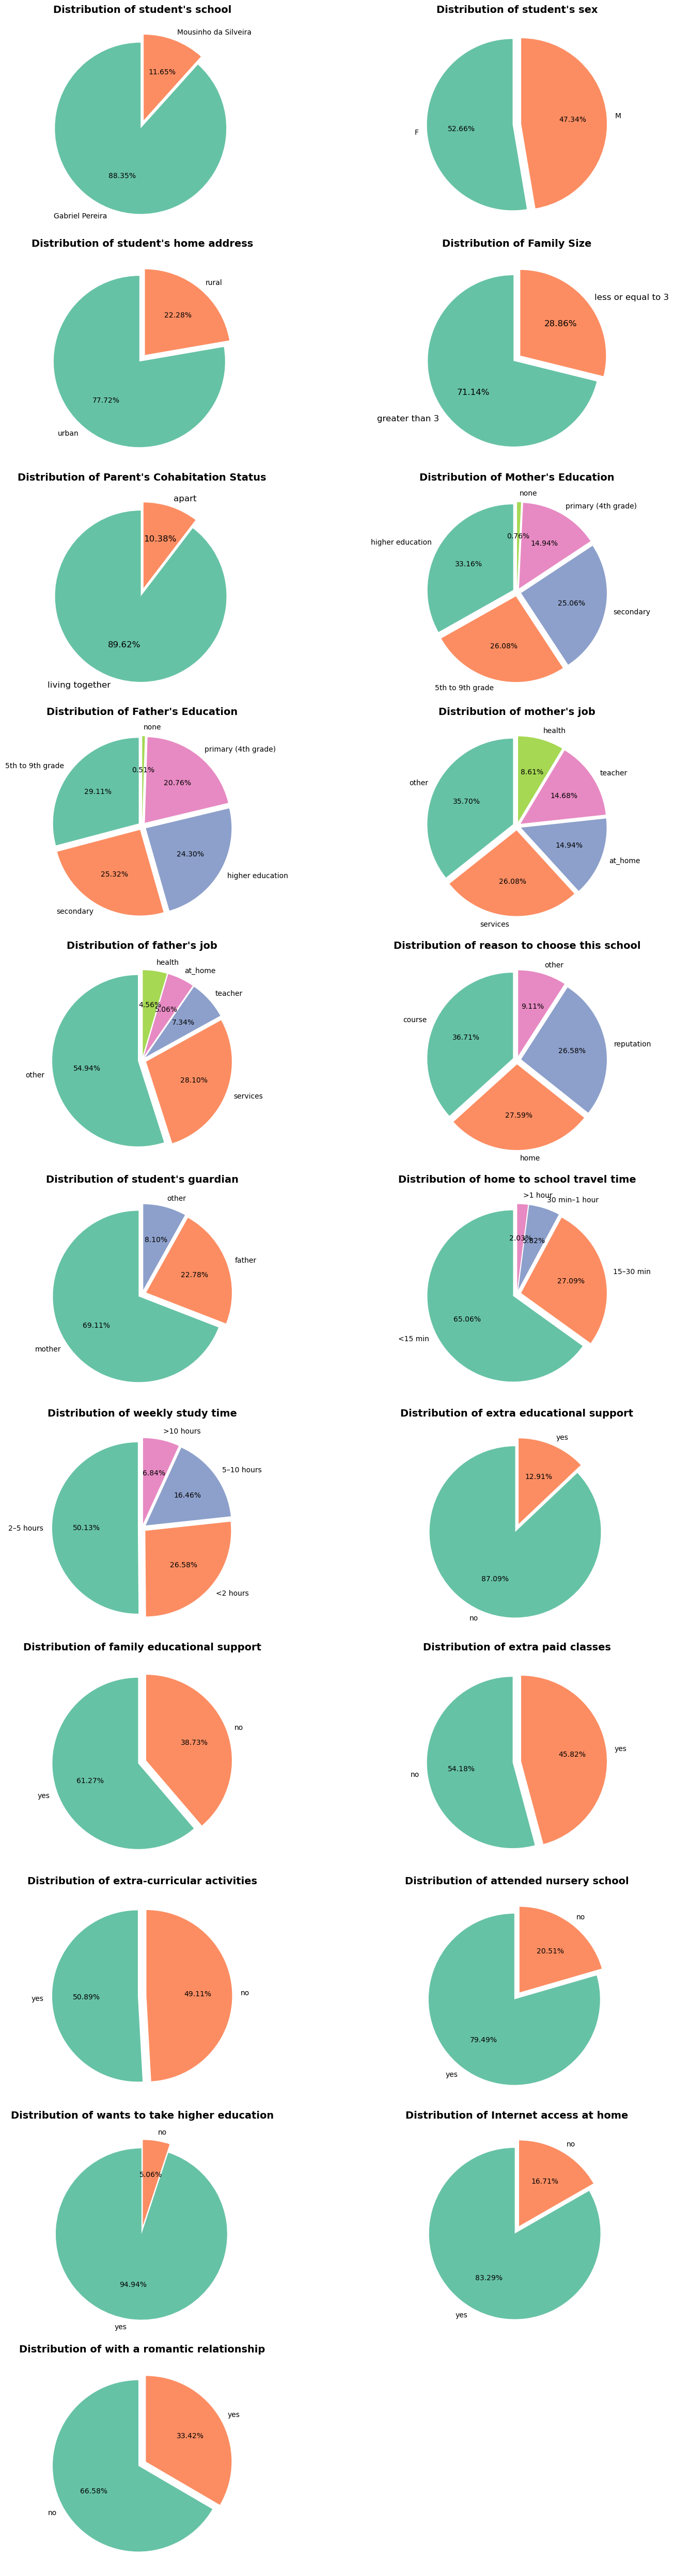

In [22]:
# Prepare the data
school = df['school'].value_counts()
sex = df['sex'].value_counts()
address = df['address'].value_counts()
famsize = df['famsize'].value_counts()
Pstatus = df['Pstatus'].value_counts()
Medu = df['Medu'].value_counts()
Fedu = df['Fedu'].value_counts()
Mjob = df['Mjob'].value_counts()
Fjob = df['Fjob'].value_counts()
reason = df['reason'].value_counts()
guardian = df['guardian'].value_counts()
traveltime = df['traveltime'].value_counts()
studytime = df['studytime'].value_counts()
schoolsup = df['schoolsup'].value_counts()
famsup = df['famsup'].value_counts()
paid = df['paid'].value_counts()
activities = df['activities'].value_counts()
nursery = df['nursery'].value_counts()
higher = df['higher'].value_counts()
internet = df['internet'].value_counts()
romantic = df['romantic'].value_counts()


fig, axes = plt.subplots(11, 2, figsize=(16, 50))

colors = sns.color_palette('Set2')

# --- Plot 1: student's school ---
axes[0, 0].pie(
    school,
    labels=school.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(school)
)
axes[0, 0].set_title("Distribution of student's school", fontsize=14, fontweight='bold')


# --- Plot 2: student's sex ---
axes[0, 1].pie(
    sex,
    labels=sex.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(sex)
)
axes[0, 1].set_title("Distribution of student's sex", fontsize=14, fontweight='bold')


# --- Plot 3: student's home address ---
axes[1, 0].pie(
    address,
    labels=address.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(address)
)
axes[1, 0].set_title("Distribution of student's home address", fontsize=14, fontweight='bold')


# --- Plot 4 : Family Size ---
axes[1, 1].pie(
    famsize,
    labels=famsize.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':12},
    explode=[0.05, 0.05]
)
axes[1, 1].set_title("Distribution of Family Size", fontsize=14, fontweight='bold')


# --- Plot 5: Parent's Cohabitation Status ---
axes[2, 0].pie(
    Pstatus,
    labels=Pstatus.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':12},
    explode=[0.05, 0.05]
)
axes[2, 0].set_title("Distribution of Parent's Cohabitation Status", fontsize=14, fontweight='bold')


# --- Plot 6: Mother's Education ---
axes[2, 1].pie(
    Medu,
    labels=Medu.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(Medu)
)
axes[2, 1].set_title("Distribution of Mother's Education", fontsize=14, fontweight='bold')


# --- Plot 7: Father's Education ---
axes[3, 0].pie(
    Fedu,
    labels=Fedu.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(Fedu)
)
axes[3, 0].set_title("Distribution of Father's Education", fontsize=14, fontweight='bold')


# --- Plot 8: mother's job ---
axes[3, 1].pie(
    Mjob,
    labels=Mjob.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(Mjob)
)
axes[3, 1].set_title("Distribution of mother's job", fontsize=14, fontweight='bold')


# --- Plot 9: father's job ---
axes[4, 0].pie(
    Fjob,
    labels=Fjob.index,
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(Fjob)
)
axes[4, 0].set_title("Distribution of father's job", fontsize=14, fontweight='bold')


# --- Plot 10 : reason to choose this school ---
axes[4, 1].pie(
    reason,
    labels=reason.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(reason)
)
axes[4, 1].set_title('Distribution of reason to choose this school', fontsize=14, fontweight='bold')


# --- Plot 11 : student's guardian ---
axes[5, 0].pie(
    guardian,
    labels=guardian.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(guardian)
)
axes[5, 0].set_title("Distribution of student's guardian", fontsize=14, fontweight='bold')


# --- Plot 12 : home to school travel time ---
axes[5, 1].pie(
    traveltime,
    labels=traveltime.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(traveltime)
)
axes[5, 1].set_title('Distribution of home to school travel time', fontsize=14, fontweight='bold')


# --- Plot 13 : weekly study time ---
axes[6, 0].pie(
    studytime,
    labels=studytime.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(studytime)
)
axes[6, 0].set_title('Distribution of weekly study time', fontsize=14, fontweight='bold')


# --- Plot 14 : extra educational support ---
axes[6, 1].pie(
    schoolsup,
    labels=schoolsup.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(schoolsup)
)
axes[6, 1].set_title('Distribution of extra educational support', fontsize=14, fontweight='bold')


# --- Plot 15 : family educational support ---
axes[7, 0].pie(
    famsup,
    labels=famsup.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(famsup)
)
axes[7, 0].set_title('Distribution of family educational support', fontsize=14, fontweight='bold')


# --- Plot 16 : extra paid classes within the course subject ---
axes[7, 1].pie(
    paid,
    labels=paid.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(paid)
)
axes[7, 1].set_title('Distribution of extra paid classes', fontsize=14, fontweight='bold')


# --- Plot 17 : extra-curricular activities ---
axes[8, 0].pie(
    activities,
    labels=activities.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(activities)
)
axes[8, 0].set_title('Distribution of extra-curricular activities', fontsize=14, fontweight='bold')


# --- Plot 18 : attended nursery school ---
axes[8, 1].pie(
    nursery,
    labels=nursery.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(nursery)
)
axes[8, 1].set_title('Distribution of attended nursery school', fontsize=14, fontweight='bold')


# --- Plot 19 : wants to take higher education ---
axes[9, 0].pie(
    higher,
    labels=higher.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(higher)
)
axes[9, 0].set_title('Distribution of wants to take higher education', fontsize=14, fontweight='bold')


# --- Plot 20 : Internet access at home ---
axes[9, 1].pie(
    internet,
    labels=internet.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(internet)
)
axes[9, 1].set_title('Distribution of Internet access at home', fontsize=14, fontweight='bold')


# --- Plot 21 : with a romantic relationship ---
axes[10, 0].pie(
    romantic,
    labels=romantic.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize':10},
    explode=[0.05]*len(romantic)
)
axes[10, 0].set_title('Distribution of with a romantic relationship', fontsize=14, fontweight='bold')
fig.delaxes(axes[10, 1])

plt.tight_layout()
plt.show()


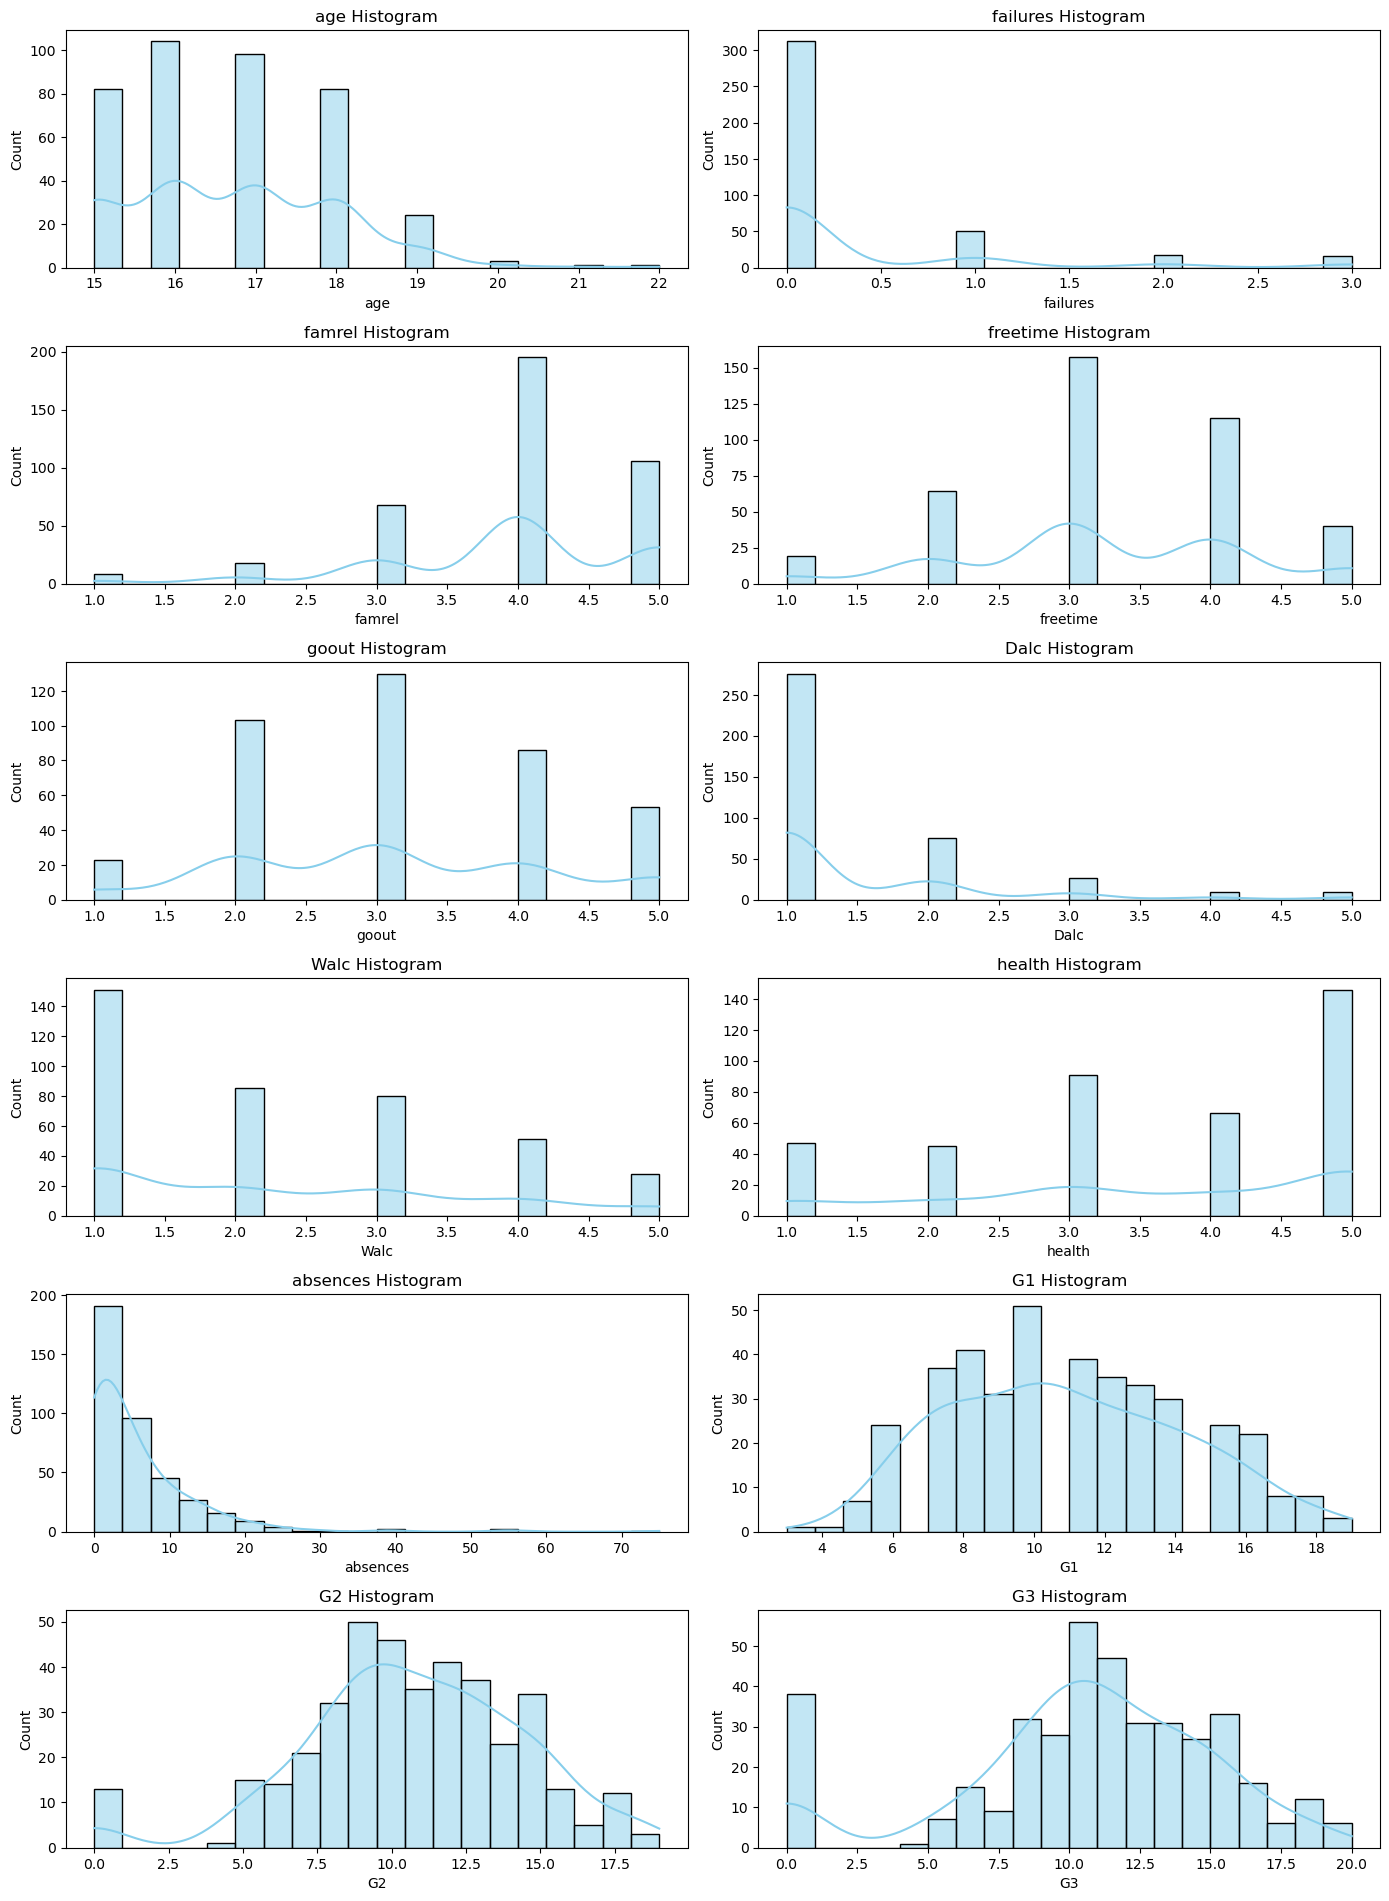

In [23]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(14, 25))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col],
                 bins= np.sqrt(len(df[col])),
                 kde=True,
                 color="skyblue",
                 ax=axes[i],
                 binwidth= round((df[col].max() - df[col].min()) / np.sqrt(len(df[col])),2)
    )
    axes[i].set_title(f"{col} Histogram", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

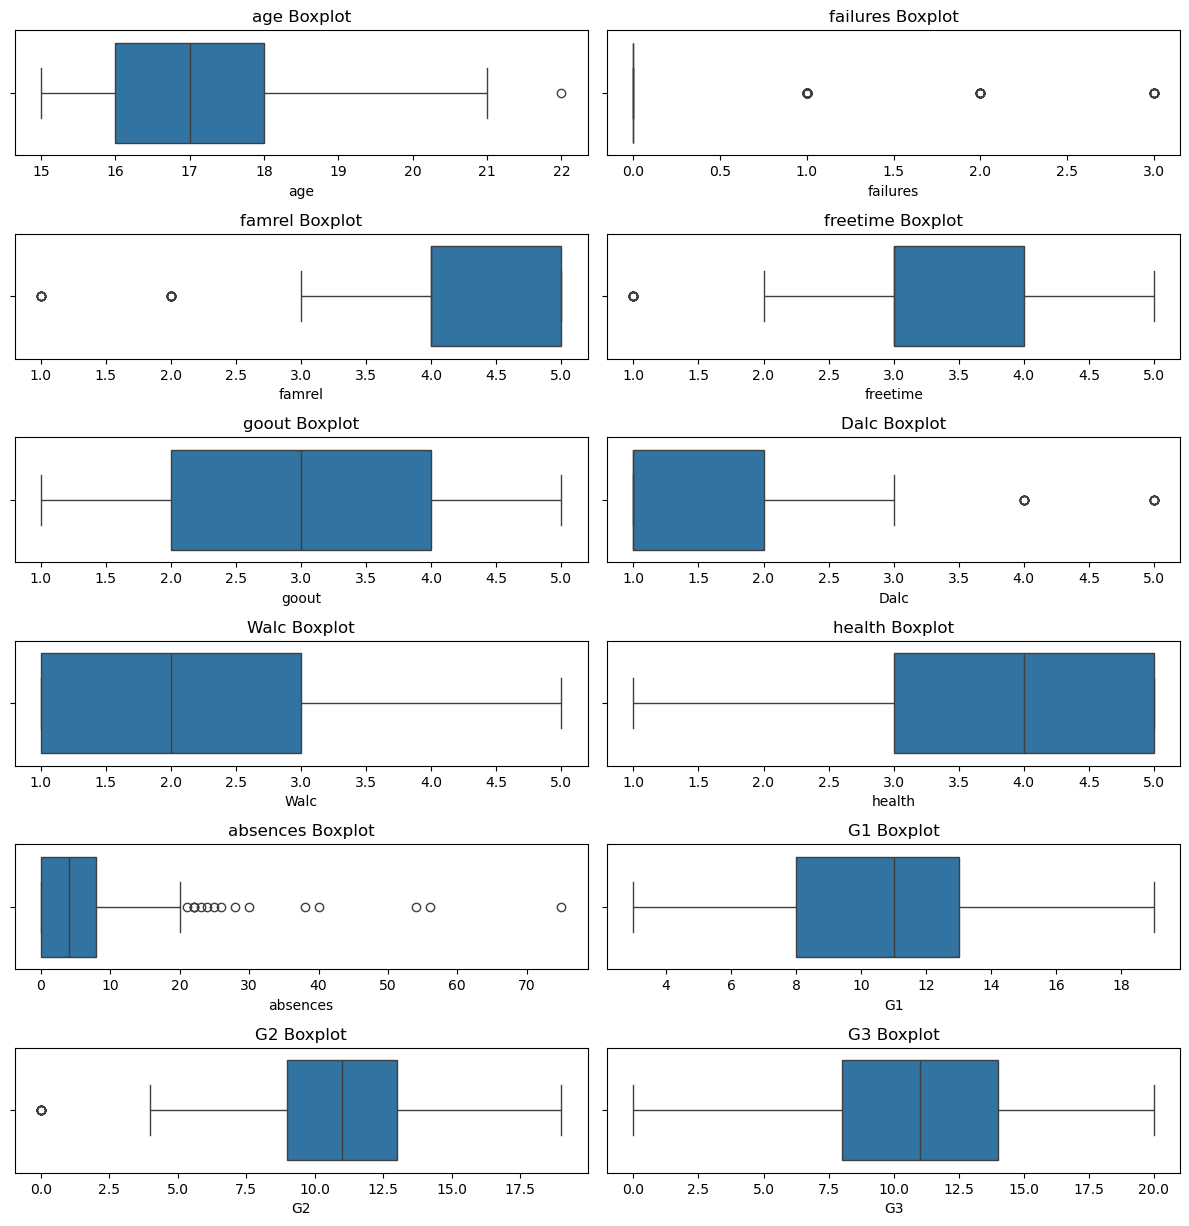

In [24]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 16))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot", fontsize=12)
    axes[i].set_ylabel("")
    axes[i].set_xlabel(col)


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate analysis

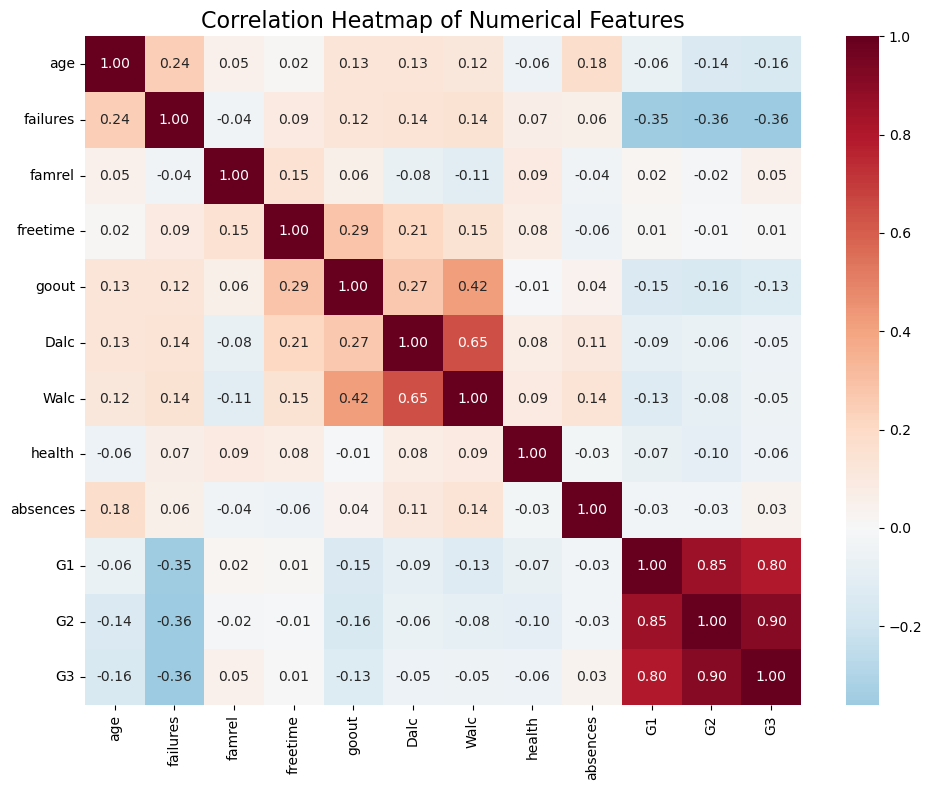

In [25]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, cbar=True)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

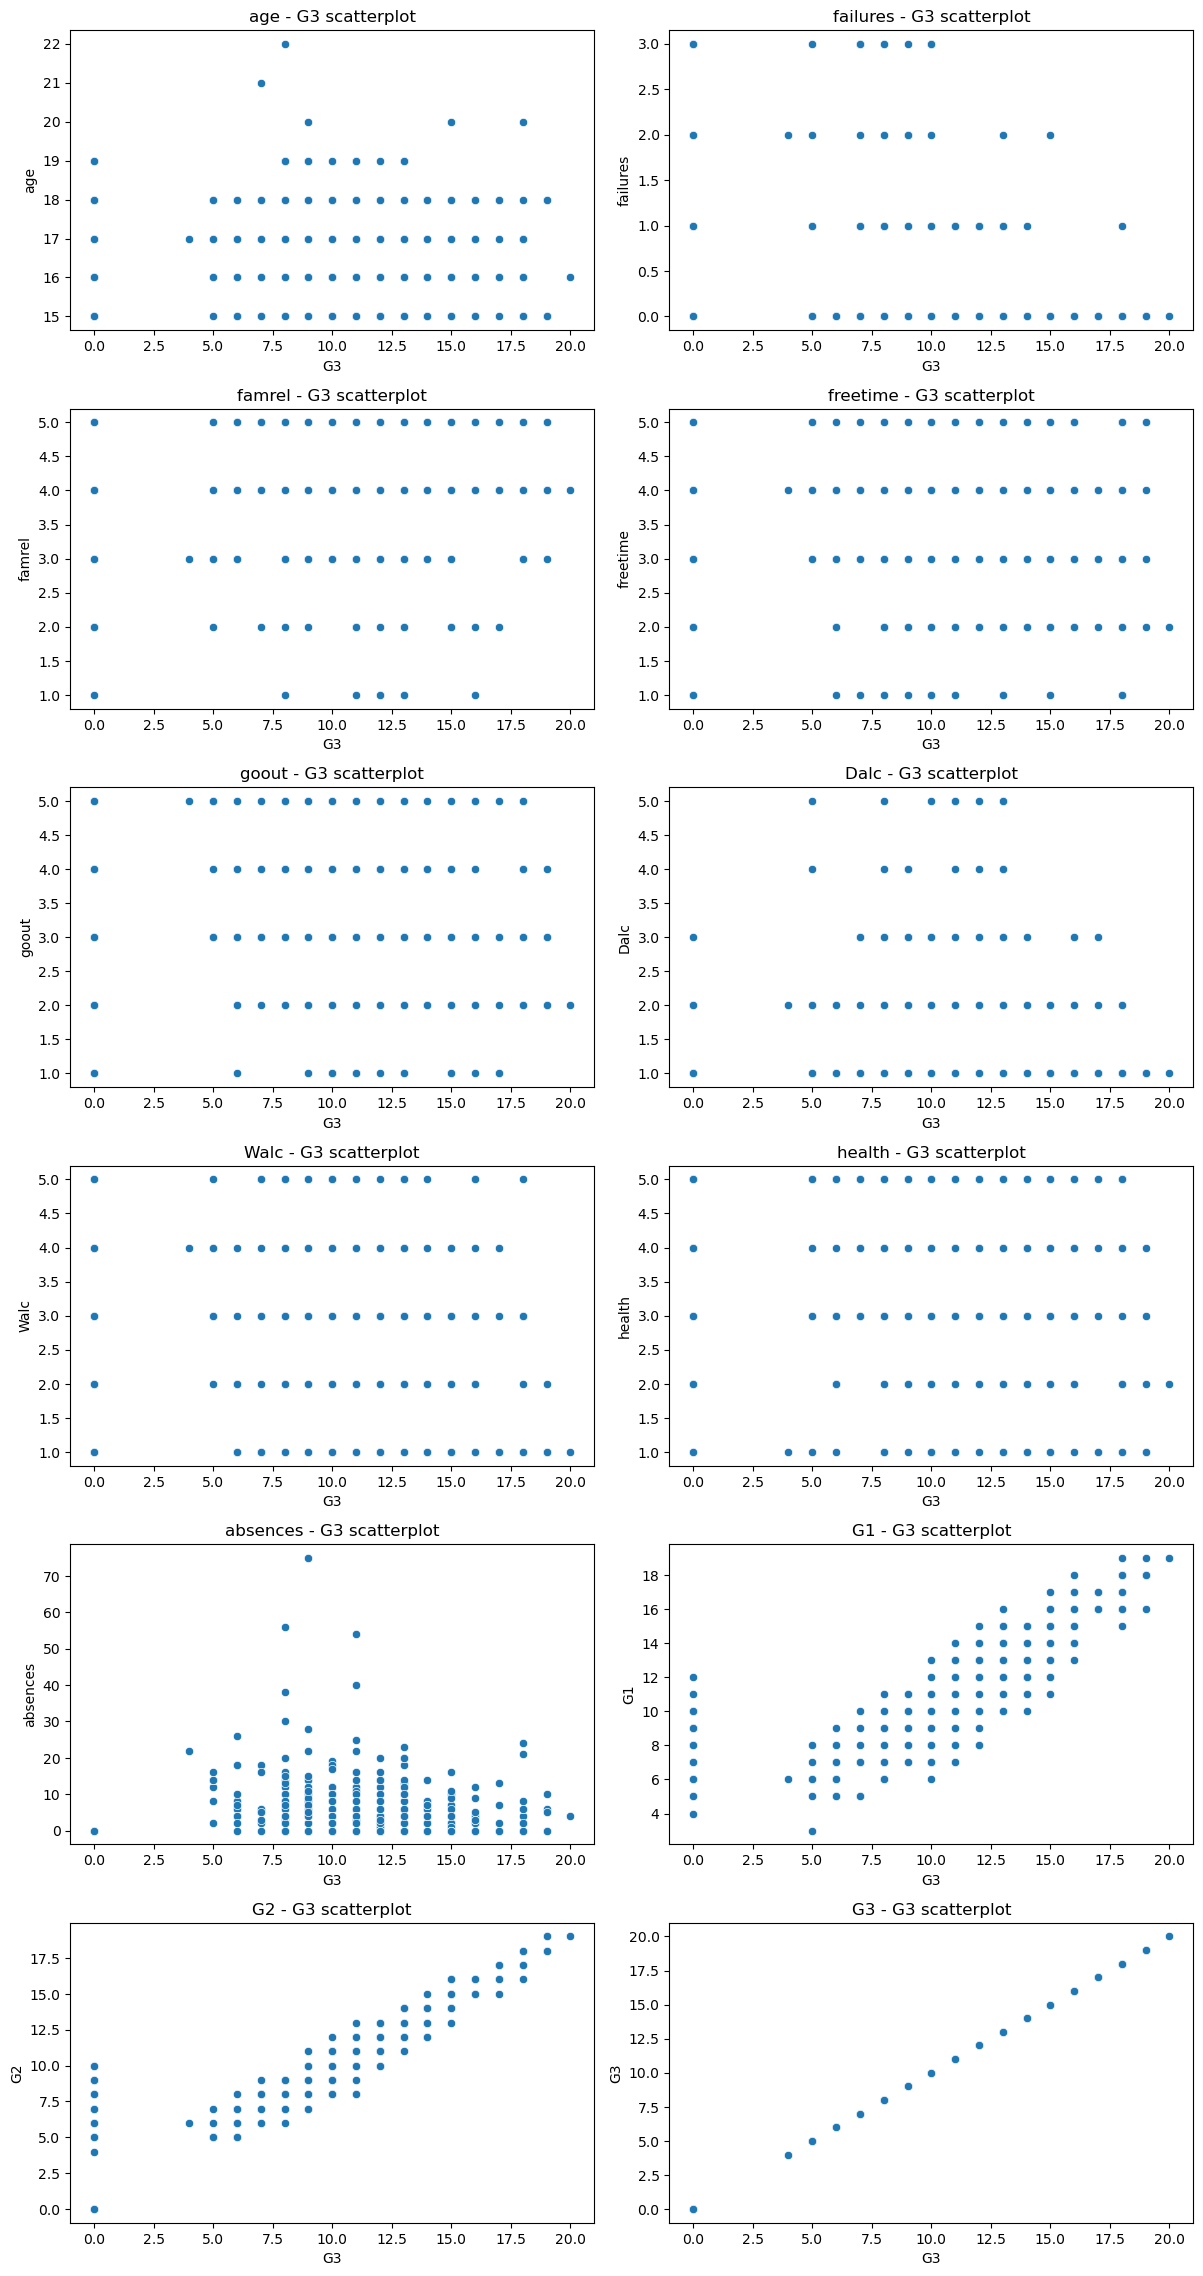

In [26]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 30))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.scatterplot(data = df, x = df['G3'], y = df[col], ax=axes[i])
    axes[i].set_title(f"{col} - G3 scatterplot", fontsize=12)
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('G3')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

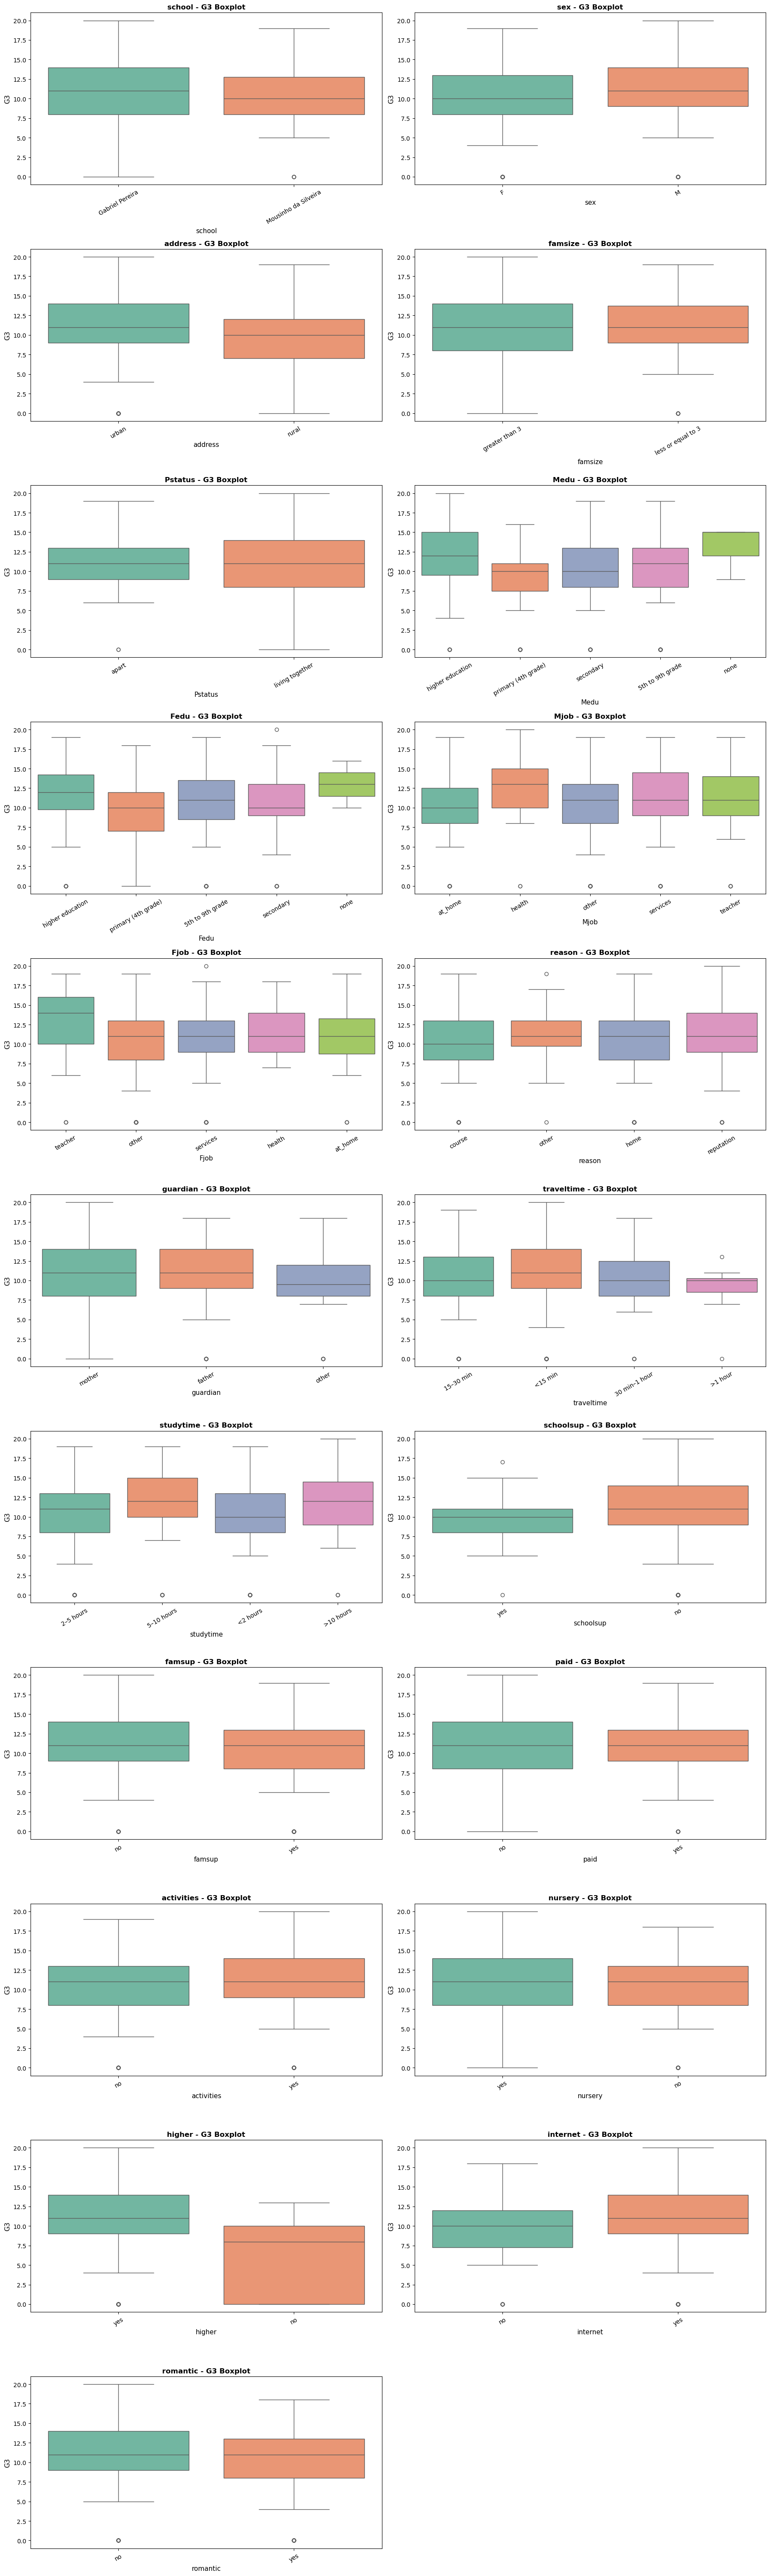

In [27]:
fig, axes = plt.subplots(nrows=11, ncols=2, figsize=(18, 60))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(
        data=df,
        x=col,
        y='G3',
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - G3 Boxplot", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('G3', fontsize=11)

    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [28]:
corr["G3"]

age        -0.161579
failures   -0.360415
famrel      0.051363
freetime    0.011307
goout      -0.132791
Dalc       -0.054660
Walc       -0.051939
health     -0.061335
absences    0.034247
G1          0.801468
G2          0.904868
G3          1.000000
Name: G3, dtype: float64

In [29]:
corr_g3 = corr["G3"].sort_values(ascending=False)
print("Top 10 correlated features with (G3):\n", corr_g3.head(10))

Top 10 correlated features with (G3):
 G3          1.000000
G2          0.904868
G1          0.801468
famrel      0.051363
absences    0.034247
freetime    0.011307
Walc       -0.051939
Dalc       -0.054660
health     -0.061335
goout      -0.132791
Name: G3, dtype: float64


# Preprocessing

## Outlier Analysis

In [30]:
def count_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((col < lower) | (col > upper)).sum()

outliers_df = (
    df[num_cols]
    .apply(count_outliers)
    .reset_index()
    .rename(columns={'index': 'Column', 0: 'Outliers_Count'})
    .sort_values(by="Outliers_Count", ascending=False)
    .reset_index(drop=True)
)

outliers_df['percentage %'] = [round((col / len(df)) * 100 , 2) for col in outliers_df['Outliers_Count']]
outliers_df

,Column,Outliers_Count,percentage %
0,failures,83,21.01
1,famrel,26,6.58
2,freetime,19,4.81
3,Dalc,18,4.56
4,absences,15,3.80
5,G2,13,3.29
6,age,1,0.25
7,goout,0,0.00
8,Walc,0,0.00
9,health,0,0.00


## Split Data

In [31]:
X=df.drop(columns="G3")
y=df["G3"]

## Data Encoding 

In [32]:
cat_cols

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic'],
      dtype='object')

In [33]:
binary_cols = []
for col in cat_cols:
    if len(df[col].value_counts().index.to_list()) <= 2:
        binary_cols.append(col)

In [34]:
binary_cols

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [35]:
for col in binary_cols:
    print(f"{col} : {df[col].value_counts().index.to_list()}")

school : ['Gabriel Pereira', 'Mousinho da Silveira']
sex : ['F', 'M']
address : ['urban', 'rural']
famsize : ['greater than 3', 'less or equal to 3']
Pstatus : ['living together', 'apart']
schoolsup : ['no', 'yes']
famsup : ['yes', 'no']
paid : ['no', 'yes']
activities : ['yes', 'no']
nursery : ['yes', 'no']
higher : ['yes', 'no']
internet : ['yes', 'no']
romantic : ['no', 'yes']


In [36]:
encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [37]:
encoders

{'school': {'Gabriel Pereira': 0, 'Mousinho da Silveira': 1},
 'sex': {'F': 0, 'M': 1},
 'address': {'rural': 0, 'urban': 1},
 'famsize': {'greater than 3': 0, 'less or equal to 3': 1},
 'Pstatus': {'apart': 0, 'living together': 1},
 'schoolsup': {'no': 0, 'yes': 1},
 'famsup': {'no': 0, 'yes': 1},
 'paid': {'no': 0, 'yes': 1},
 'activities': {'no': 0, 'yes': 1},
 'nursery': {'no': 0, 'yes': 1},
 'higher': {'no': 0, 'yes': 1},
 'internet': {'no': 0, 'yes': 1},
 'romantic': {'no': 0, 'yes': 1}}

In [38]:
X.select_dtypes(include = 'object').columns.to_list()

['Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime']

In [39]:
X.shape

(395, 32)

In [40]:
X = pd.get_dummies(
    X,
    columns= X.select_dtypes(include = 'object').columns.to_list(),
    drop_first=False
    )

In [41]:
X.shape

(395, 59)

In [42]:
X.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences', 'G1', 'G2', 'Medu_5th to 9th grade',
       'Medu_higher education', 'Medu_none', 'Medu_primary (4th grade)',
       'Medu_secondary', 'Fedu_5th to 9th grade', 'Fedu_higher education',
       'Fedu_none', 'Fedu_primary (4th grade)', 'Fedu_secondary',
       'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_father',
       'guardian_mother', 'guardian_other', 'traveltime_15–30 min',
       'traveltime_30 min–1 hour', 'traveltime_<15 min', 'traveltime_>1 hour',
       'studytime_2–5 hours', 'studytime_5–10 hours', 'studytime_<2 hours'

In [43]:
y

0       6
1       6
2      10
3      15
4      10
       ..
390     9
391    16
392     7
393    10
394     9
Name: G3, Length: 395, dtype: int64

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape : {y_test.shape}')

X_train shape : (316, 59)
X_test shape : (79, 59)
y_train shape : (316,)
y_test shape : (79,)


# Model Training and Evaluation

## Linear Regression

In [46]:
LR = LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [47]:
y_pred_LR = LR.predict(X_test)

In [48]:
r2_LR = r2_score(y_test, y_pred_LR)

mae_LR = mean_absolute_error(y_test, y_pred_LR)
mse_LR = mean_squared_error(y_test, y_pred_LR)


print("R² Score:", r2_LR)
print("MSE:", mse_LR)
print('MAE:', mae_LR)

R² Score: 0.6702869353161575
MSE: 6.7607819762411
MAE: 1.8974485759493671


# KNN

In [49]:
n_neighbors= [i for i in range(1,20)]
for n in n_neighbors:
    print(f"for n_neighbors : {n}")
    KNN = KNeighborsRegressor(n_neighbors=n)
    KNN.fit(X_train,y_train)
    
    y_pred_KNN = KNN.predict(X_test)
    
    r2_KNN = r2_score(y_test, y_pred_KNN)

    mae_KNN = mean_absolute_error(y_test, y_pred_KNN)
    mse_KNN = mean_squared_error(y_test, y_pred_KNN)


    print("R² Score:", r2_KNN)
    print("MSE:", mse_KNN)
    print('MAE:', mae_KNN)
    print("---------------------")
    print("")

for n_neighbors : 1
R² Score: 0.587628543743944
MSE: 8.455696202531646
MAE: 1.7721518987341771
---------------------

for n_neighbors : 2
R² Score: 0.7438111461882286
MSE: 5.253164556962025
MAE: 1.3924050632911393
---------------------

for n_neighbors : 3
R² Score: 0.7664463059627626
MSE: 4.789029535864979
MAE: 1.379746835443038
---------------------

for n_neighbors : 4
R² Score: 0.7926953747694808
MSE: 4.250791139240507
MAE: 1.2816455696202531
---------------------

for n_neighbors : 5
R² Score: 0.7831222454912012
MSE: 4.447088607594937
MAE: 1.3139240506329113
---------------------

for n_neighbors : 6
R² Score: 0.7969866238100696
MSE: 4.162798874824191
MAE: 1.3270042194092828
---------------------

for n_neighbors : 7
R² Score: 0.8162772532511895
MSE: 3.767243606303281
MAE: 1.3254972875226043
---------------------

for n_neighbors : 8
R² Score: 0.8097006815944113
MSE: 3.9020965189873418
MAE: 1.3306962025316456
---------------------

for n_neighbors : 9
R² Score: 0.8019995114672076


In [50]:
KNN = KNeighborsRegressor(n_neighbors=7)
KNN.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=7)

In [51]:
y_pred_KNN = KNN.predict(X_test)

Text(0.5, 1.0, 'Actual VS Predicted Values(KNN)')

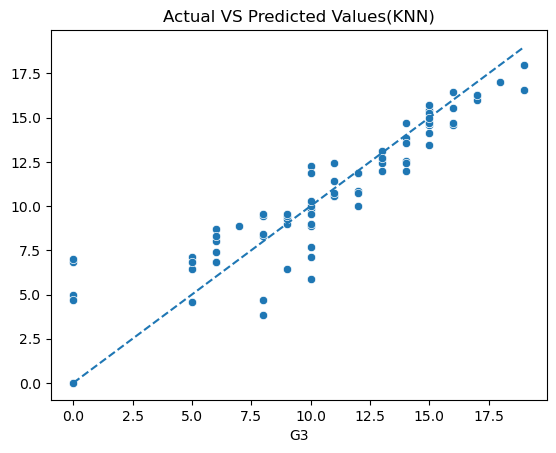

In [66]:
sns.scatterplot(x=y_test,y=y_pred_KNN)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.title("Actual VS Predicted Values(KNN)")

In [52]:
r2_KNN = r2_score(y_test, y_pred_KNN)

mae_KNN = mean_absolute_error(y_test, y_pred_KNN)
mse_KNN = mean_squared_error(y_test, y_pred_KNN)


print("R² Score:", r2_KNN)
print("MSE:", mse_KNN)
print('MAE:', mae_KNN)

R² Score: 0.8162772532511895
MSE: 3.767243606303281
MAE: 1.3254972875226043


## Decision Tree

In [53]:
ccp_alph = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.001]
for ccp in ccp_alph:
    print(f"for ccp_alpha : {ccp}")
    DT = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp)
    DT.fit(X_train,y_train)
    
    y_pred_DT = DT.predict(X_test)
    
    r2_DT = r2_score(y_test, y_pred_DT)
    mse_DT = mean_squared_error(y_test, y_pred_DT)
    mae_DT = mean_absolute_error(y_test, y_pred_DT)


    print("R² Score:", r2_DT)
    print("MSE:", mse_DT)
    print('MAE:', mae_DT)
    print("---------------------")
    print("")

for ccp_alpha : 0.01
R² Score: 0.7484013039377522
MSE: 5.159043155340167
MAE: 1.2073737039720076
---------------------

for ccp_alpha : 0.02
R² Score: 0.7384502345489262
MSE: 5.363090303525848
MAE: 1.2446511310042558
---------------------

for ccp_alpha : 0.03
R² Score: 0.7484135020790728
MSE: 5.158793031875805
MAE: 1.2295135494109781
---------------------

for ccp_alpha : 0.04
R² Score: 0.7563484116686705
MSE: 4.996087335673274
MAE: 1.2162224101704717
---------------------

for ccp_alpha : 0.05
R² Score: 0.7581783937352816
MSE: 4.958563466897699
MAE: 1.204334683147907
---------------------

for ccp_alpha : 0.06
R² Score: 0.7624220479314463
MSE: 4.871547137016016
MAE: 1.211371440948524
---------------------

for ccp_alpha : 0.07
R² Score: 0.7624220479314463
MSE: 4.871547137016016
MAE: 1.211371440948524
---------------------

for ccp_alpha : 0.08
R² Score: 0.7580425601073641
MSE: 4.96134874185874
MAE: 1.2265318575981436
---------------------

for ccp_alpha : 0.09
R² Score: 0.75804256010

In [54]:
DT = DecisionTreeRegressor(ccp_alpha = 0.06, random_state=42)
DT.fit(X_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.06, random_state=42)

In [55]:
y_pred_DT = DT.predict(X_test)

In [56]:
r2_DT = r2_score(y_test, y_pred_DT)
mse_DT = mean_squared_error(y_test, y_pred_DT)
mae_DT = mean_absolute_error(y_test, y_pred_DT)


print("R² Score:", r2_DT)
print("MSE:", mse_DT)
print('MAE:', mae_DT)

R² Score: 0.7624220479314463
MSE: 4.871547137016016
MAE: 1.211371440948524


## Evaluation Metric: R² Score

In [57]:
# Create R²_Score dictionary
R2_Score = {
    "Decision Tree": r2_DT,
    "KNN": r2_KNN,
    "Linear Regression": r2_LR
}

# Convert the R²_Score results to a DataFrame
R2_Score_df = pd.DataFrame.from_dict(R2_Score, orient='index', columns=['R² Score'])

R2_Score_df = R2_Score_df.sort_values(by='R² Score', ascending=False)

print(R2_Score_df)

                   R² Score
KNN                0.816277
Decision Tree      0.762422
Linear Regression  0.670287


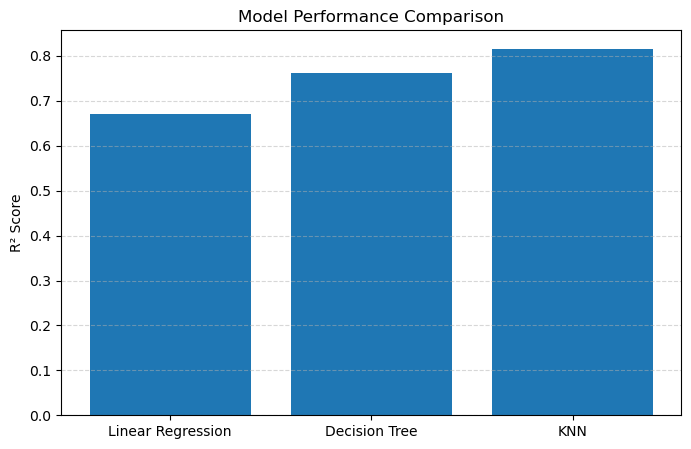

In [60]:
models = ['Linear Regression', 'Decision Tree', 'KNN']
scores = [r2_LR, r2_DT, r2_KNN]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Final Model Selection — **KNN**

After evaluating multiple models, **KNN** was selected as the optimal model

## Key Insights from Model Analysis

Academic progress features **G1** and **G2** had the **strongest influence** on the final grade (**G3**).  

In [58]:
print(X.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Medu_5th to 9th grade', 'Medu_higher education', 'Medu_none', 'Medu_primary (4th grade)', 'Medu_secondary', 'Fedu_5th to 9th grade', 'Fedu_higher education', 'Fedu_none', 'Fedu_primary (4th grade)', 'Fedu_secondary', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'traveltime_15–30 min', 'traveltime_30 min–1 hour', 'traveltime_<15 min', 'traveltime_>1 hour', 'studytime_2–5 hours', 'studytime_5–10 hours', 'studytime_<2 hours', 'studytime_>10 hours']


## Saving Trained Model

In [59]:
import joblib
joblib.dump(KNN, "model.pkl")

['model.pkl']